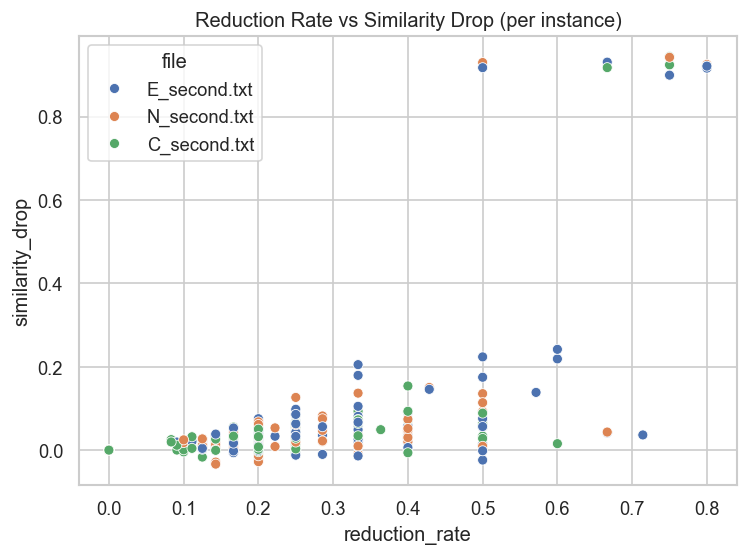

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../summary_sentence_embedding.csv")

sns.scatterplot(data=df, x="reduction_rate", y="similarity_drop", hue="file")
plt.title("Reduction Rate vs Similarity Drop (per instance)")
plt.tight_layout()
plt.savefig("reduction_vs_similarity_drop.png")



Valid values: 8845/8845
Average: 0.5154


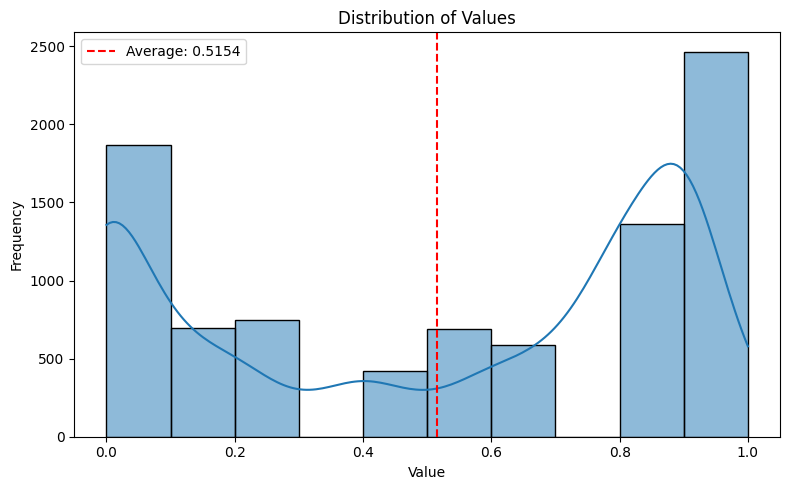

In [20]:
# average and distribution of scores
import json
import matplotlib.pyplot as plt
import seaborn as sns
import math

with open('/Users/phoebeeeee/ongoing/LLM_AED/new_processing/validation_result/all_peer/llama_8b_all_peer/llama_8b.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

raw_values = list(data.values())
values = []
for v in raw_values:
    try:
        x = float(v)  
        if not math.isnan(x):
            values.append(x)
    except (TypeError, ValueError):
        print("bad:", v) 
        # print("bad detail:", repr(v), [hex(ord(ch)) for ch in str(v)])
        pass 

print(f"Valid values: {len(values)}/{len(raw_values)}")
if values:
    average = sum(values) / len(values)
    print(f"Average: {average:.4f}")

    plt.figure(figsize=(8, 5))
    sns.histplot(values, bins=10, kde=True)

    plt.axvline(average, color='red', linestyle='--', label=f'Average: {average:.4f}')
    plt.title('Distribution of Values')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No valid numeric values to plot.")


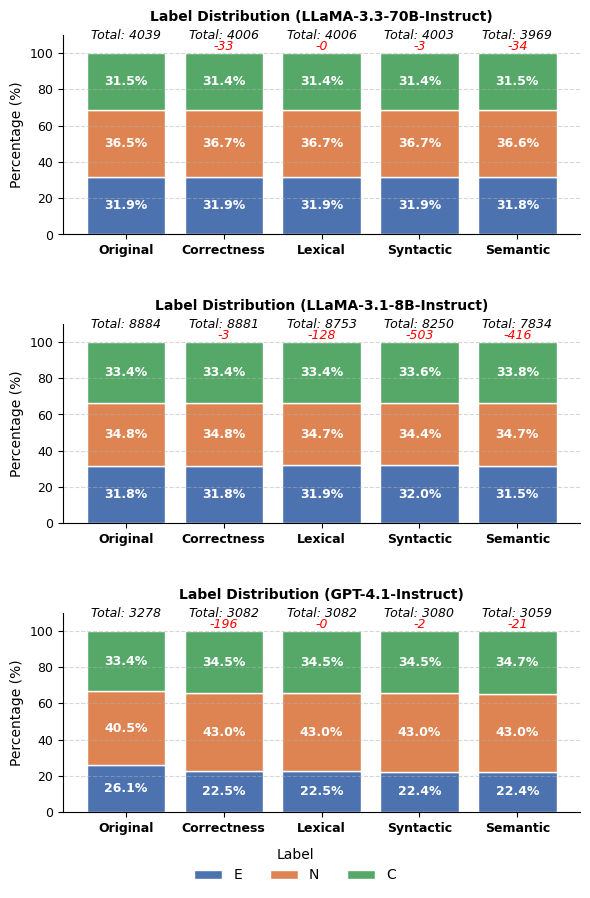

In [20]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["E", "N", "C"]
stages = ["Original", "Correctness", "Lexical", "Syntactic", "Semantic"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
models = {
    "LLaMA-3.3-70B-Instruct": [[1289, 1476, 1274], [1278, 1469, 1259], [1278, 1469, 1259], [1278, 1469, 1256], [1263, 1454, 1252]],
    "LLaMA-3.1-8B-Instruct":  [[2823, 3092, 2969], [2821, 3091, 2969], [2795, 3033, 2925], [2641, 2841, 2768], [2470, 2716, 2648]],
    "GPT-4.1-Instruct":       [[857, 1326, 1095], [692, 1326, 1064], [692, 1326, 1064], [691, 1325, 1064], [685, 1314, 1060]]
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 9))
axes = axes.flatten()

for ax, (model_name, counts) in zip(axes, models.items()):
    arr = np.array(counts, dtype=float)
    sums = arr.sum(axis=1)
    percentages = arr / sums[:, None] * 100
    bottom = np.zeros(len(stages))

    for i, (label, color) in enumerate(zip(labels, colors)):
        bars = ax.bar(stages, percentages[:, i], label=label, bottom=bottom, color=color, edgecolor='white', linewidth=1)
        for j, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.1f}%",
                    ha='center', va='center',
                    color='white' if height > 15 else 'black',
                    fontsize=9, weight='bold')
        bottom += percentages[:, i]

    for j, total in enumerate(sums):
        ax.text(j, 106, f"Total: {int(total)}", ha='center', va='bottom', fontsize=9, style='italic')
    for j in range(1, len(sums)):
        delta = int(sums[j - 1] - sums[j])
        ax.text(j, 100, f"-{delta}", ha='center', va='bottom', fontsize=9, color='red', style='italic')


    ax.set_title(f"Label Distribution ({model_name})", weight='bold', pad=10, fontsize = 10)
    ax.set_ylabel("Percentage (%)", fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_xticks(np.arange(len(stages)))
    ax.set_xticklabels(stages, fontweight='bold')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Label", loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0))

plt.tight_layout(h_pad=3.0, rect=[0, 0.05, 1, 1])
plt.savefig("../label_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()


In [2]:
import pandas as pd

# 手动填入数据（按表格顺序）
data = {
    "Llama-8B": {
        "before":     [0.382,0.191,0.103, 0.841,0.483,0.265, 0.599,0.542],
        "one-expl":   [0.382,0.189,0.101, 0.840,0.483,0.264, 0.608,0.545],
        "one-llm":    [0.378,0.183,0.097, 0.842,0.484,0.263, 0.611,0.545],
        "all-llm":    [0.380,0.186,0.099, 0.842,0.483,0.263, 0.606,0.544],
    },
    "Llama-70B": {
        "before":     [0.310,0.100,0.030, 0.841,0.444,0.201, 0.595,0.535],
        "one-expl":   [0.313,0.100,0.031, 0.840,0.445,0.201, 0.606,0.539],
        "one-llm":    [0.308,0.097,0.029, 0.838,0.446,0.200, 0.605,0.538],
        "all-llm":    [0.309,0.097,0.029, 0.836,0.447,0.202, 0.608,0.540],
    },
    "Qwen-7B": {
        "before":     [0.211,0.050,0.010, 0.804,0.409,0.160, 0.533,0.517],
        "one-expl":   [0.219,0.053,0.012, 0.806,0.411,0.161, 0.548,0.521],
        "one-llm":    [0.207,0.048,0.010, 0.804,0.415,0.164, 0.536,0.518],
        "all-llm":    [0.200,0.042,0.010, 0.805,0.428,0.170, 0.536,0.518],
    },
    "Qwen-72B": {
        "before":     [0.266,0.083,0.023, 0.824,0.431,0.188, 0.578,0.530],
        "one-expl":   [0.270,0.084,0.023, 0.824,0.431,0.189, 0.583,0.532],
        "one-llm":    [0.265,0.079,0.021, 0.824,0.432,0.187, 0.583,0.531],
        "all-llm":    [0.263,0.080,0.022, 0.823,0.435,0.191, 0.584,0.532],
    }
}

metrics = ["lex1","lex2","lex3","pos1","pos2","pos3","cosine","euclidean"]

# 转成长表
rows = []
for model, settings in data.items():
    for setting, vals in settings.items():
        for metric, score in zip(metrics, vals):
            rows.append([model, setting, metric, score])

df_long = pd.DataFrame(rows, columns=["model","setting","metric","score"])

print(df_long)


        model  setting     metric  score
0    Llama-8B   before       lex1  0.382
1    Llama-8B   before       lex2  0.191
2    Llama-8B   before       lex3  0.103
3    Llama-8B   before       pos1  0.841
4    Llama-8B   before       pos2  0.483
..        ...      ...        ...    ...
123  Qwen-72B  all-llm       pos1  0.823
124  Qwen-72B  all-llm       pos2  0.435
125  Qwen-72B  all-llm       pos3  0.191
126  Qwen-72B  all-llm     cosine  0.584
127  Qwen-72B  all-llm  euclidean  0.532

[128 rows x 4 columns]


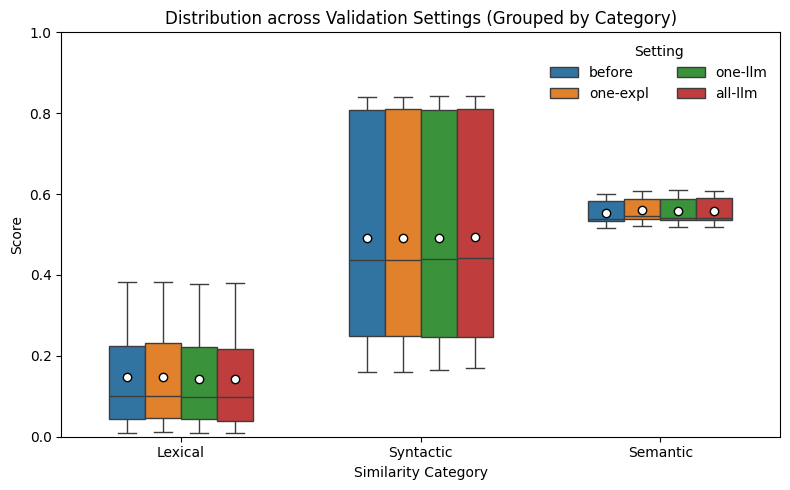

In [3]:
import seaborn as sns, matplotlib.pyplot as plt

# 新增 family 分组列
lex = {"lex1", "lex2", "lex3"}
pos = {"pos1", "pos2", "pos3"}
sem = {"cosine", "euclidean"}

df_long["family"] = df_long["metric"].map(
    lambda m: "Lexical" if m in lex else
              "Syntactic" if m in pos else
              "Semantic"
)

# 绘图
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_long,
    x="family", y="score", hue="setting",
    order=["Lexical","Syntactic","Semantic"],
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"},
    width=0.6
)

plt.ylim(0,1)
plt.xlabel("Similarity Category")
plt.ylabel("Score")
plt.title("Distribution across Validation Settings (Grouped by Category)")
plt.legend(title="Setting", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


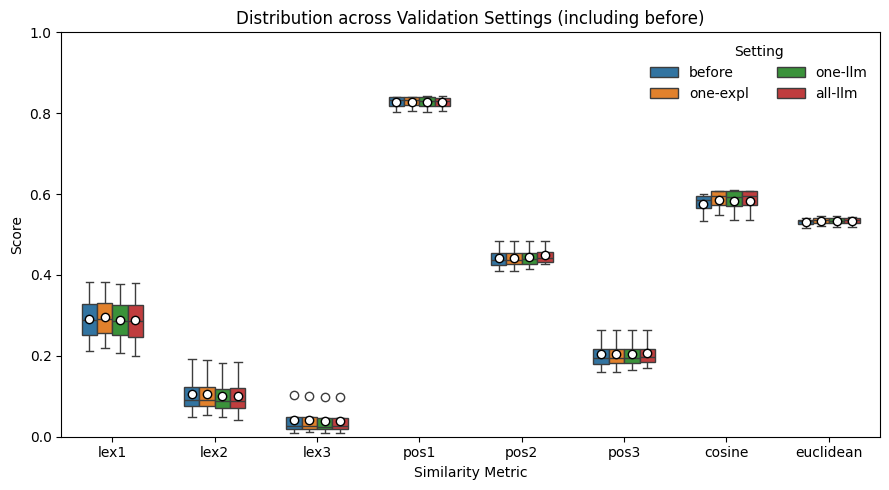

In [28]:
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_long,
    x="metric", y="score", hue="setting",
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"},
    width=0.6  # 稍微缩窄箱体，避免重叠
)

# 去掉散点（删掉或注释掉这行）
# sns.stripplot(...)

plt.ylim(0,1)
plt.xlabel("Similarity Metric")
plt.ylabel("Score")
plt.title("Distribution across Validation Settings (including before)")
plt.legend(title="Setting", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [10]:
# -*- coding: utf-8 -*-
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW = r"""
\multicolumn{11}{l}{\textit{within-llm}} \\
\multirow{4}{*}{\, Llama-8B}
& before     & 0.382 & 0.191 & 0.103 & 0.841 & 0.483 & 0.265 & 0.599 & 0.542 & / \\
& one-expl   & 0.382 & 0.189 & 0.101 & 0.840 & 0.483 & 0.264 & 0.608 & 0.545 & / \\
& one-llm    & 0.378 & 0.183 & 0.097 & 0.842 & 0.484 & 0.263 & 0.611 & 0.545 & / \\
& all-llm    & 0.380 & 0.186 & 0.099 & 0.842 & 0.483 & 0.263 & 0.606 & 0.544 & / \\
\hline
\multirow{4}{*}{\, Llama-70B}
& before     & 0.310 & 0.100 & 0.030 & 0.841 & 0.444 & 0.201 & 0.595 & 0.535 & / \\
& one-expl   & 0.313 & 0.100 & 0.031 & 0.840 & 0.445 & 0.201 & 0.606 & 0.539 & / \\
& one-llm    & 0.308 & 0.097 & 0.029 & 0.838 & 0.446 & 0.200 & 0.605 & 0.538 & / \\
& all-llm    & 0.309 & 0.097 & 0.029 & 0.836 & 0.447 & 0.202 & 0.608 & 0.540 & / \\
\hline
\multirow{4}{*}{\, Qwen-7B}
& before     & 0.211 & 0.050 & 0.010 & 0.804 & 0.409 & 0.160 & 0.533 & 0.517 & / \\
& one-expl   & 0.219 & 0.053 & 0.012 & 0.806 & 0.411 & 0.161 & 0.548 & 0.521 & / \\
& one-llm    & 0.207 & 0.048 & 0.010 & 0.804 & 0.415 & 0.164 & 0.536 & 0.518 & / \\
& all-llm    & 0.200 & 0.042 & 0.010 & 0.805 & 0.428 & 0.170 & 0.536 & 0.518 & / \\
\hline
\multirow{4}{*}{\, Qwen-72B}
& before     & 0.266 & 0.083 & 0.023 & 0.824 & 0.431 & 0.188 & 0.578 & 0.530 & / \\
& one-expl   & 0.270 & 0.084 & 0.023 & 0.824 & 0.431 & 0.189 & 0.583 & 0.532 & / \\
& one-llm    & 0.265 & 0.079 & 0.021 & 0.824 & 0.432 & 0.187 & 0.583 & 0.531 & / \\
& all-llm    & 0.263 & 0.080 & 0.022 & 0.823 & 0.435 & 0.191 & 0.584 & 0.532 & / \\
\midrule
\multicolumn{11}{l}{\textit{llm-vs-human}} \\
\multirow{4}{*}{\, Llama-8B}
& before     & 0.233 & 0.062 & 0.020 & 0.742 & 0.308 & 0.116 & 0.450 & 0.497 & / \\
& one-expl   & 0.234 & 0.062 & 0.020 & 0.739 & 0.307 & 0.116 & 0.452 & 0.498 & / \\
& one-llm    & 0.233 & 0.061 & 0.019 & 0.742 & 0.310 & 0.117 & 0.453 & 0.498 & / \\
& all-llm    & 0.233. &  0.060& 0.018 & 0.745 & 0.309 &0.116&  0.453 & 0.498 & / \\
\hline
\multirow{4}{*}{\, Llama-70B}
& before     & 0.257 & 0.079 & 0.028 & 0.754 & 0.322 & 0.129 & 0.515 & 0.514 & / \\
& one-expl   & 0.262 & 0.081 & 0.029 & 0.755 & 0.325 & 0.131 & 0.521 & 0.516 & / \\
& one-llm    & 0.262 & 0.082 & 0.029 & 0.756 & 0.326 & 0.132 & 0.521 & 0.516 & / \\
& all-llm    & 0.263 & 0.083 & 0.030 & 0.753 & 0.326 & 0.132 & 0.523 & 0.517 & / \\
\hline
\multirow{4}{*}{\, Qwen-7B}
& before     & 0.207 & 0.052 & 0.015 & 0.727 & 0.293 & 0.101 & 0.469 & 0.502 & / \\
& one-expl   & 0.213 & 0.054 & 0.016 & 0.728 & 0.296 & 0.103 & 0.477 & 0.504 & / \\
& one-llm    & 0.206 &  0.052 & 0.015& 0.725 & 0.293 & 0.100 & 0.469 & 0.502 & / \\
& all-llm    & 0.199 & 0.048 & 0.014 & 0.716 & 0.288 & 0.095 & 0.470 &  0.502 & / \\
\hline
\multirow{4}{*}{\, Qwen-72B}
& before     & 0.245 & 0.072 & 0.023 & 0.749 & 0.323 & 0.125 & 0.502 & 0.511 & / \\
& one-expl   & 0.248 & 0.074 & 0.024 & 0.748 & 0.324 & 0.127 & 0.506 & 0.512 & / \\
& one-llm    & 0.247 & 0.073 & 0.023 & 0.747 & 0.324 & 0.126 & 0.507 & 0.512 & / \\
& all-llm    & 0.247 & 0.073 & 0.024 & 0.745 & 0.324 & 0.126 & 0.504 & 0.512 & / \\
"""


/var/folders/m4/bdfxxbj17j90t407ws9bzdrm0000gn/T/ipykernel_20342/3824953587.py:66: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m4/bdfxxbj17j90t407ws9bzdrm0000gn/T/ipykernel_20342/3824953587.py:66: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m4/bdfxxbj17j90t407ws9bzdrm0000gn/T/ipykernel_20342/3824953587.py:66: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m4/bdfxxbj17j90t407ws9bzdrm0000gn/T/ipykernel_20342/3824953587.py:66: UserWarning: Glyph 36328 (\N{CJK UNIFIED IDEOGRAPH-8DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m4/bdfxxbj17j90t407ws9bzdrm0000gn/T/ipykernel_20342/3824953587.py:66: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m4/bdfx

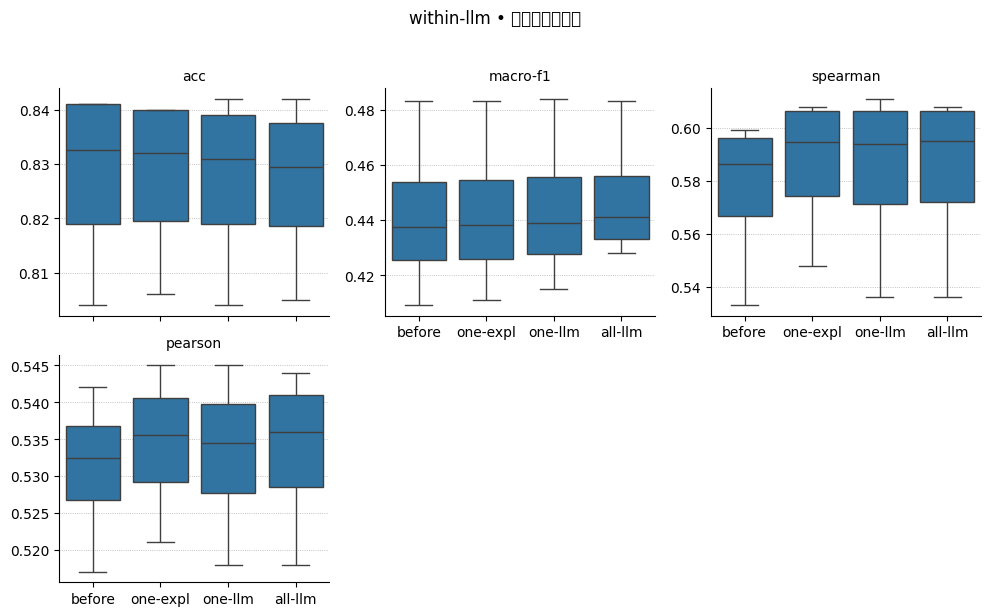

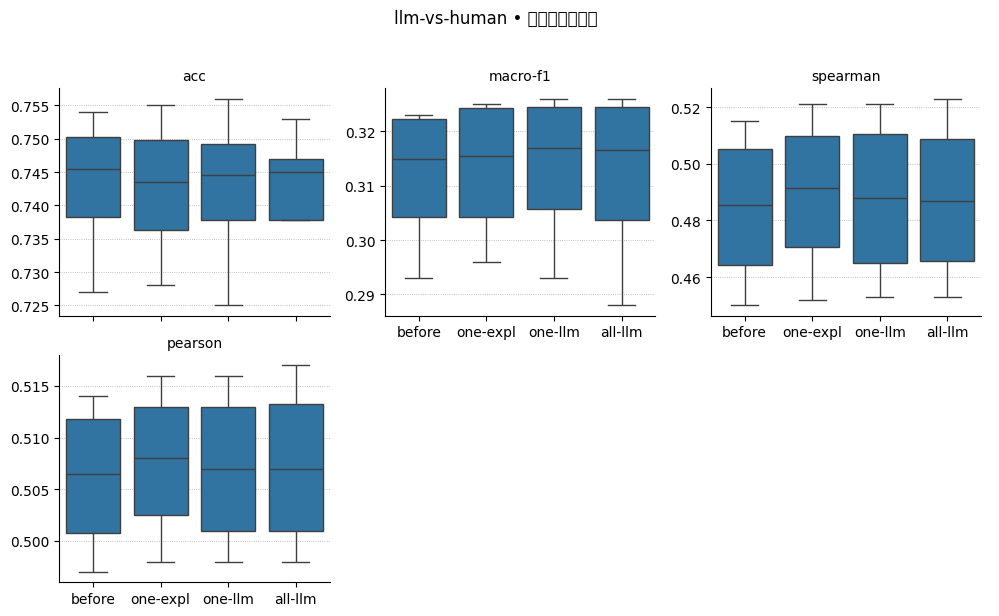

/opt/anaconda3/envs/ma/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ma/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


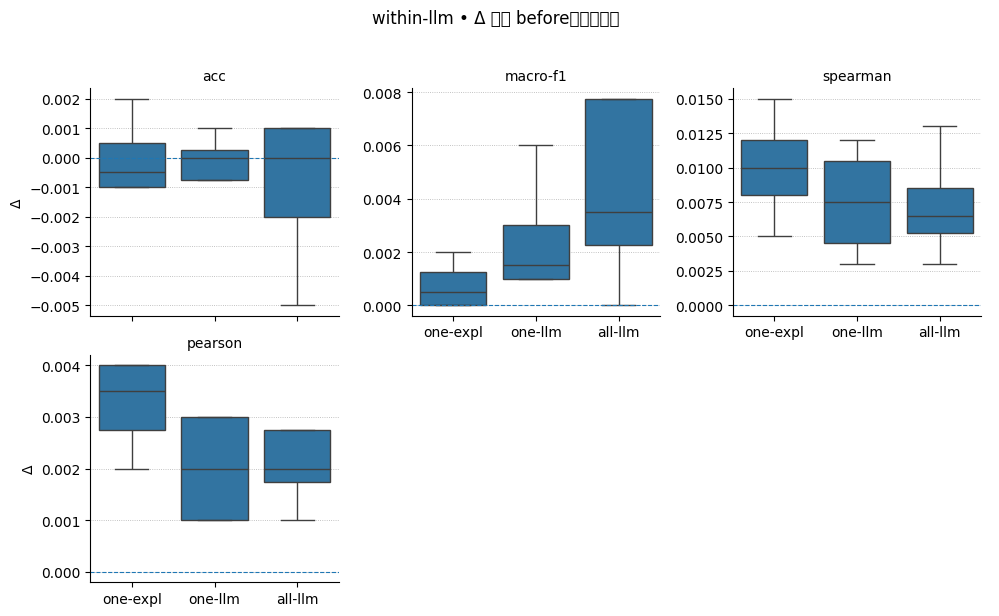

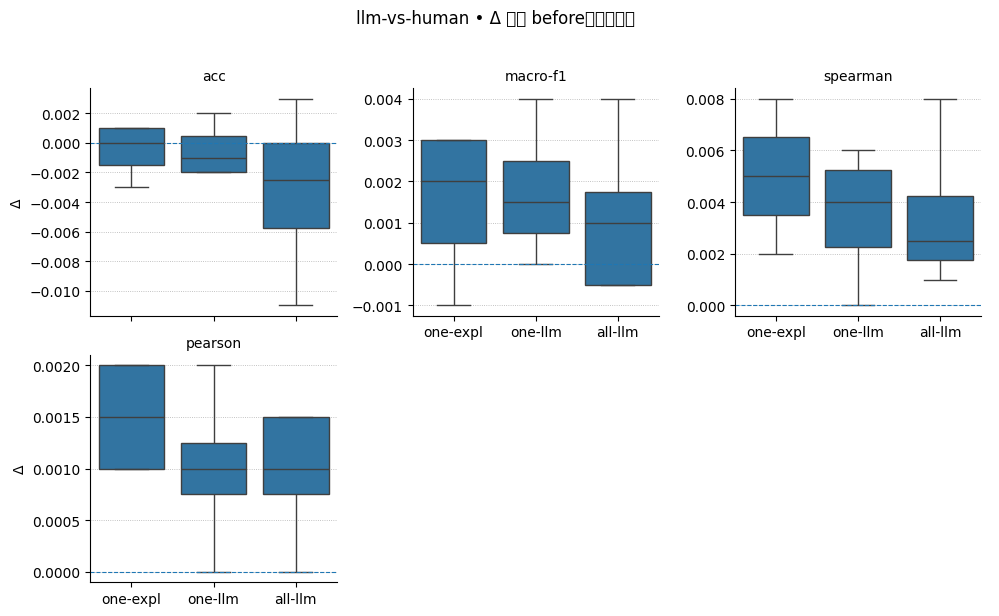

In [11]:
# -*- coding: utf-8 -*-
import re, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 解析 ----------
group = None
rows, model = [], None
for line in io.StringIO(RAW):
    line = line.strip()
    if not line:
        continue
    mgrp = re.search(r'\{\\textit\{([^}]+)\}\}', line)
    if mgrp:
        group = mgrp.group(1)
        continue
    mmod = re.search(r'\{\\,\s*([^}]+)\}', line)
    if mmod:
        model = mmod.group(1).strip()
        continue
    if line.startswith('&'):
        parts = [p.strip() for p in line.split('&')]
        setting = parts[1].replace('\\', '').strip()
        nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', line)
        vals = list(map(float, nums))[:9]  # 9个指标
        rows.append({
            "group": group, "model": model, "setting": setting,
            **{f"m{i+1}": v for i, v in enumerate(vals)}
        })

df = pd.DataFrame(rows)
df["setting"] = pd.Categorical(df["setting"],
    categories=["before","one-expl","one-llm","all-llm"], ordered=True)
df["model"] = pd.Categorical(df["model"],
    categories=["Llama-8B","Llama-70B","Qwen-7B","Qwen-72B"], ordered=True)
df["group"] = pd.Categorical(df["group"],
    categories=["within-llm","llm-vs-human"], ordered=True)

metric_names = {
    "m1":"kld","m2":"jsd","m3":"emd",
    "m4":"acc","m5":"macro-f1","m6":"micro-f1",
    "m7":"spearman","m8":"pearson","m9":"auc"
}
df = df.rename(columns=metric_names)

# ---------- Boxplot：各 setting 的分布（跨模型） ----------
def box_by_setting(df, group, metrics):
    sub = df[df.group==group]
    long = sub.melt(
        id_vars=["model","setting"], value_vars=metrics,
        var_name="metric", value_name="score"
    )
    g = sns.catplot(
        data=long, kind="box",
        x="setting", y="score", col="metric", col_wrap=3,
        order=["before","one-expl","one-llm","all-llm"],
        height=3, aspect=1.1, sharey=False, showfliers=False
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("", "")
    for ax in g.axes.flatten():
        ax.grid(True, axis="y", linestyle=":", linewidth=0.6)
    plt.suptitle(f"{group} • 分布（跨模型）", y=1.02)
    plt.tight_layout()

# ---------- Boxplot：Δ 相对 before（跨模型） ----------
def box_delta_vs_before(df, group, metrics):
    sub = df[df.group==group].copy()
    long = sub.melt(
        id_vars=["model","setting"], value_vars=metrics,
        var_name="metric", value_name="score"
    )
    base = long[long.setting=="before"][["model","metric","score"]].rename(columns={"score":"base"})
    merged = long.merge(base, on=["model","metric"], how="left")
    merged = merged[merged.setting!="before"].copy()
    merged["delta"] = merged["score"] - merged["base"]

    g = sns.catplot(
        data=merged, kind="box",
        x="setting", y="delta", col="metric", col_wrap=3,
        order=["one-expl","one-llm","all-llm"],
        height=3, aspect=1.1, sharey=False, showfliers=False
    )
    # 以0为参考线
    for ax in g.axes.flatten():
        ax.axhline(0, ls="--", lw=0.8)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.6)
    g.set_titles("{col_name}")
    g.set_axis_labels("", "Δ")
    plt.suptitle(f"{group} • Δ 相对 before（跨模型）", y=1.02)
    plt.tight_layout()

# 选择你关心的指标
metrics_main = ["acc","macro-f1","spearman","pearson"]

# 画图
box_by_setting(df, "within-llm", metrics_main)
box_by_setting(df, "llm-vs-human", metrics_main)
box_delta_vs_before(df, "within-llm", metrics_main)
box_delta_vs_before(df, "llm-vs-human", metrics_main)
plt.show()


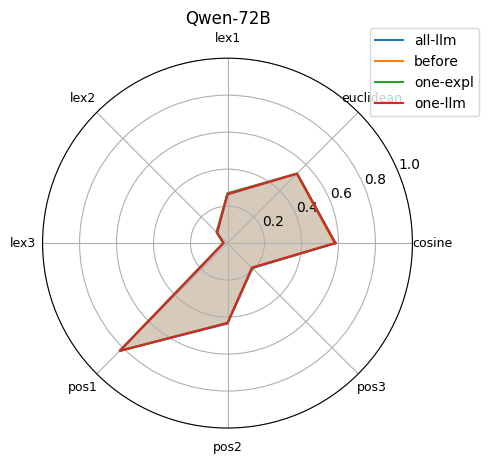

In [29]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd

def radar_for_model(model_name):
    pivot = df_long[df_long["model"]==model_name].pivot(index="setting", columns="metric", values="score")
    metrics = pivot.columns.tolist()
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(5,5))
    for s in pivot.index:
        values = pivot.loc[s].tolist() + [pivot.loc[s, metrics[0]]]
        ax.plot(angles, values, label=s)
        ax.fill(angles, values, alpha=0.1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0,1)
    plt.title(model_name); plt.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))
    plt.tight_layout()
    plt.show()

radar_for_model("Qwen-72B")



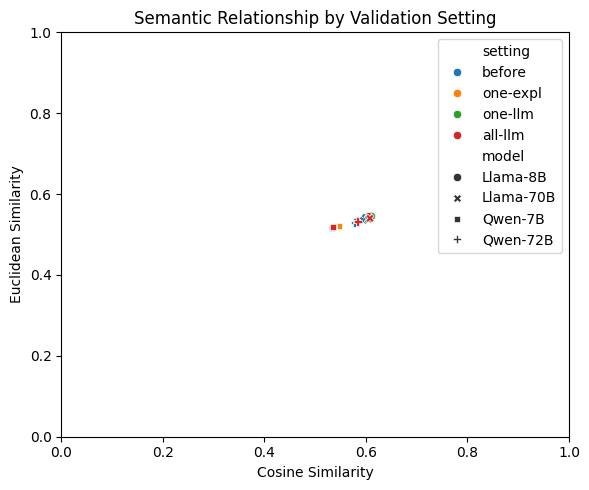

In [31]:
cos = df_long[df_long["metric"]=="cosine"].rename(columns={"score":"cosine"})
euc = df_long[df_long["metric"]=="euclidean"].rename(columns={"score":"euclidean"})
sem = cos.merge(euc, on=["model","setting"])

plt.figure(figsize=(6,5))
sns.scatterplot(data=sem, x="cosine", y="euclidean", hue="setting", style="model")
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("Cosine Similarity"); plt.ylabel("Euclidean Similarity")
plt.title("Semantic Relationship by Validation Setting")
plt.tight_layout()


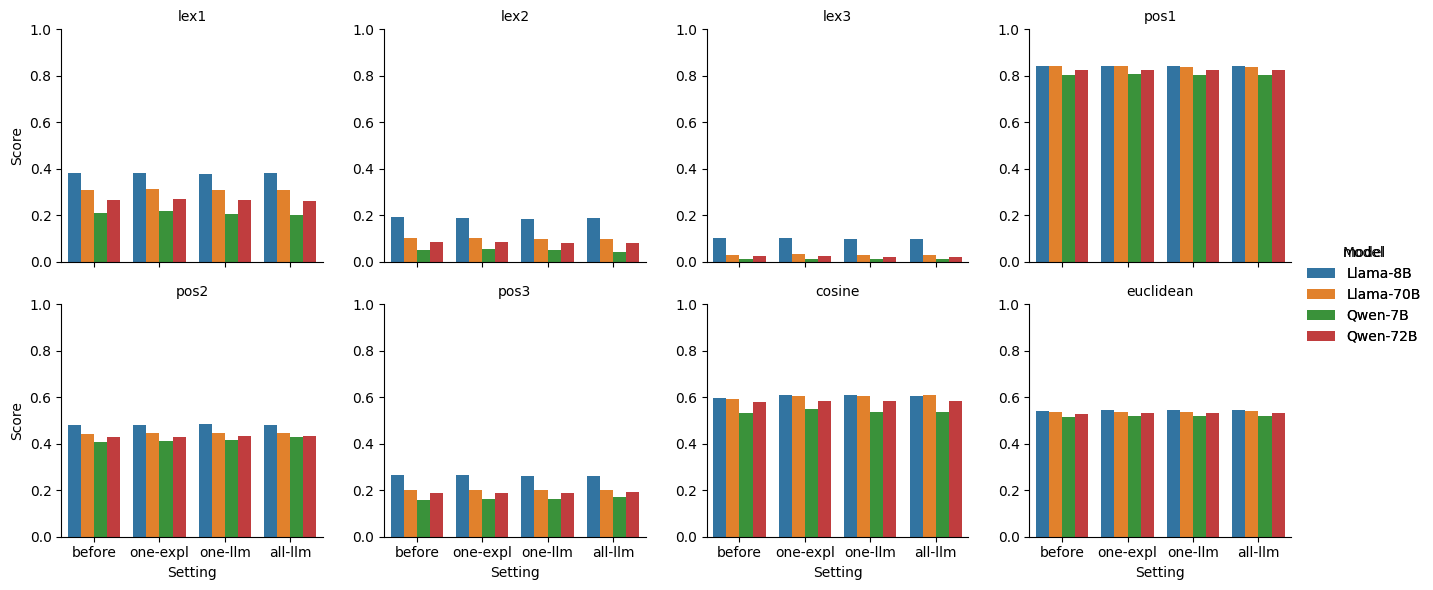

In [7]:
import seaborn as sns

g = sns.catplot(data=df_long, kind="bar",
                x="setting", y="score", hue="model",
                col="metric", col_wrap=4, height=3, sharey=False)
g.set_titles("{col_name}")
g.set_axis_labels("Setting","Score")
for ax in g.axes.flatten(): ax.set_ylim(0,1)
g.add_legend(title="Model")


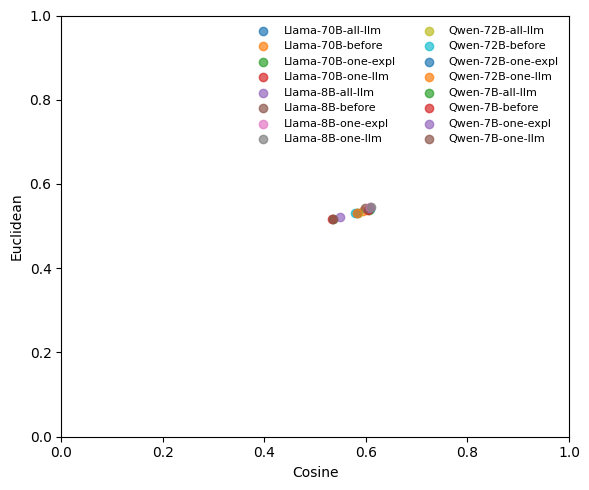

In [8]:
import pandas as pd, matplotlib.pyplot as plt

cos = df_long[df_long["metric"]=="cosine"].rename(columns={"score":"cosine"}) \
      .drop(columns=["metric"])
euc = df_long[df_long["metric"]=="euclidean"].rename(columns={"score":"euclidean"}) \
      .drop(columns=["metric"])
semi = pd.merge(cos, euc, on=["model","setting"])

plt.figure(figsize=(6,5))
for (m,s), sub in semi.groupby(["model","setting"]):
    plt.scatter(sub["cosine"], sub["euclidean"], label=f"{m}-{s}", alpha=0.7)
plt.xlabel("Cosine"); plt.ylabel("Euclidean")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()



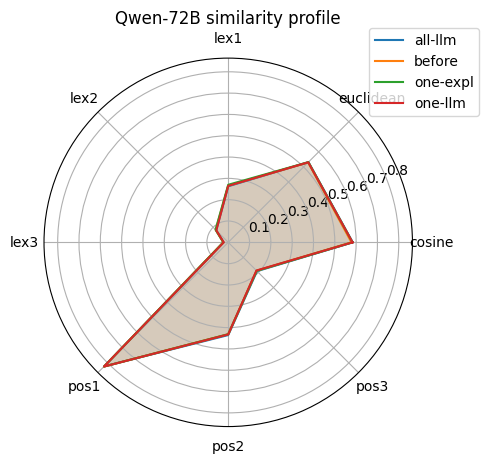

In [12]:
import matplotlib.pyplot as plt, numpy as np

def radar(values_dict, title):
    metrics = list(values_dict["before"].keys())
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, polar=True)
    for setting, vals in values_dict.items():
        v = list(vals.values()); v += v[:1]
        ax.plot(angles, v, label=setting); ax.fill(angles, v, alpha=0.1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics)
    plt.title(title); plt.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))
    plt.tight_layout()

# 示例：一个模型
values = df_long[df_long.model=="Qwen-72B"].pivot(index="setting", columns="metric", values="score").to_dict("index")
radar(values, "Qwen-72B similarity profile")
